<a href="https://colab.research.google.com/github/San123desh/.net/blob/master/data_attributes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#source --> https://www.rkuhler.com/blog/chapter-2-1-data-objects-and-attribute-types/
#Chapter 2.1 provided information about the different types of attributes or features that we can find in data.

In [26]:
import pandas as pd


In [27]:
#setup google drive
from google.colab import drive


In [28]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
#can use linux commands
!ls

drive  sample_data


In [30]:
#locate file in google drive (uploaded it separately)
#data source: https://datasets.imdbws.com/
content_file = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.tsv',sep='\t')

In [31]:
title_file=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titles.tsv',sep='\t',low_memory=False)

In [32]:
#combine two data files
data=pd.merge(title_file,content_file,on="tconst")

In [33]:
#sample data
data.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",5.7,1702
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",6.1,210
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance",6.5,1462
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short",6.2,123
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short",6.2,2262


In [34]:
#Ok, let’s have a look at all of the attributes we have to work with.
data.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating',
       'numVotes'],
      dtype='object')

In [35]:
#The first type of attribute that the book covers is nominal or categorical attributes.
#There are some obvious ones here like primaryTitle and genres.
data['genres'].value_counts()

,count
genres,
Comedy,82994
Drama,73277
Documentary,50425
"Action,Adventure,Animation",27797
Reality-TV,19843
...,...
"Comedy,Musical,Thriller",1
"Documentary,Thriller,War",1
"Action,Animation,Western",1


In [36]:
#What genre is the mode here?
#Answer:Comedy

In [37]:
#The next type of attribute that the book covers is binary. This would cover true/false type data.
data['isAdult'].value_counts()

,count
isAdult,
0,928836
1,18324
2020,1
2014,1


In [38]:
#The next type of attribute from the book is ordinal.
#The most obvious example here would be the rating of the movie.
data['averageRating'].value_counts()

,count
averageRating,
7.2,33796
7.0,32394
7.6,32220
7.8,31930
7.4,31563
...,...
1.5,273
1.4,254
1.2,194


In [39]:
#These are numerical and can be ordered from worst to best but we wouldn’t say that a 4 star movie is twice as good as a 2 star movie.
#This type of attribute, while numerical, is still qualitative and not quantitative.

In [40]:
#Next up are “interval-scaled numeric attributes”.
#We have the movie’s year of release in our data set which is one of the direct example types from the book.
#we create intervals first
data['startYear'].unique()
data['startYear'].value_counts()

,count
startYear,
2014,41618
2013,41451
2012,41042
2015,38830
2011,38593
...,...
1889,2
1878,2
1877,1


In [41]:
#create time intervals and count the number of movies in every 10 years interval 1893-1903, and so on
#Answer:

def get_interval(year):
  #Convert year to integer if it is a string
  if isinstance(year, str):
    try:
      year = int(year)
    except ValueError:
      return "Unknown"

  start_interval = (year//10)*10
  end_interval = start_interval + 9
  return f'{start_interval}-{end_interval}'
data['interval'] = data['startYear'].apply(get_interval)

# Group by interval and count the number of movies in each interval
result = data.groupby('interval').size().reset_index(name='count')

print(result)

     interval   count
0   1870-1879       4
1   1880-1889       8
2   1890-1899    2642
3   1900-1909    2814
4   1910-1919    4209
5   1920-1929    5874
6   1930-1939   12532
7   1940-1949   12256
8   1950-1959   27577
9   1960-1969   46951
10  1970-1979   55893
11  1980-1989   73623
12  1990-1999  115288
13  2000-2009  247997
14  2010-2019  287574
15  2020-2029   51798
16    Unknown     122


In [42]:

type(data['startYear'][0])

str

In [43]:
def range(startYear):
  if startYear>=1893 and startYear<=1903 :
    return '1893-1903'
  elif startYear>1903 and startYear<=1913 :
    return '1903-1913'
  elif startYear>1913 and startYear<=1923 :
    return '1913-1923'
  elif startYear>1923 and startYear<=1933 :
    return '1923-1933'
  else:
    return '1933-2021'

In [44]:
data=data[data['startYear']!='\\N']

In [45]:
data['startYear']=data['startYear'].apply(int)

In [46]:
data['year']=data['startYear'].apply(range)

In [47]:
data

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,interval,year
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",5.7,1702,1890-1899,1893-1903
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",6.1,210,1890-1899,1933-2021
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance",6.5,1462,1890-1899,1933-2021
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short",6.2,123,1890-1899,1933-2021
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short",6.2,2262,1890-1899,1893-1903
...,...,...,...,...,...,...,...,...,...,...,...,...,...
947157,tt5258388,movie,American Gospel: Christ Alone,American Gospel: Christ Alone,0,2018,\N,139,Documentary,8.7,833,2010-2019,1933-2021
947158,tt5258390,movie,Ricky,Ricky,0,2016,\N,137,"Romance,Thriller",7.9,786,2010-2019,1933-2021
947159,tt5258426,tvSeries,Volga 30 päivässä,Volga 30 päivässä,0,2016,2016,43,Documentary,7.1,40,2010-2019,1933-2021
947160,tt5258442,short,I Am Yup'ik,I Am Yup'ik,0,2016,\N,17,"Documentary,Short",7.5,37,2010-2019,1933-2021


In [48]:
data['year'].value_counts()

,count
year,
1933-2021,927154
1923-1933,8465
1913-1923,4238
1893-1903,3716
1903-1913,3467


In [49]:
#We have many “ratio-scaled numeric attributes” in our data set.
#Example: the count of ratings.
#Unlike interval-scaled attributes, these have a true zero point and can be compared as ratios of different values.
data['numVotes'].unique()
data['averageRating'].value_counts()


,count
averageRating,
7.2,33790
7.0,32392
7.6,32218
7.8,31922
7.4,31561
...,...
1.5,273
1.4,254
1.2,194


In [67]:
#create rating intervals 0.0-1.0,1.1-2.0, and so on to count the number of movies in each category
#Answer:
def get_rating_interval(rating):
  if rating >= 0.0 and rating <=1.0:
    return '0.0-1.0'
  elif rating > 1.0 and rating <= 2.0:
    return '1.1-2.0'
  elif rating > 2.0 and rating <= 3.0:
    return '2.1-3.0'
  elif rating > 3.0 and rating <= 4.0:
    return '3.1-4.0'
  elif rating > 4.0 and rating <= 5.0:
    return '4.1-5.0'
  elif rating > 5.0 and rating <= 6.0:
    return '5.1-6.0'
  elif rating > 6.0 and rating <= 7.0:
    return '6.1-7.0'
  elif rating > 7.0 and rating <= 8.0:
    return '7.1-8.0'
  elif rating > 8.0 and rating <= 9.0:
    return '8.1-9.0'
  elif rating > 9.0 and rating <= 10.0:
    return '9.1-10.0'
  else:
    return 'Unknown'

data['rating_interval'] = data['averageRating'].apply(get_rating_interval)

# Group by rating interval and count the number of movies in each interval
result = data.groupby('rating_interval').size().reset_index(name='count')

print(result)


  rating_interval   count
0         0.0-1.0     626
1         1.1-2.0    3051
2         2.1-3.0   10062
3         3.1-4.0   24579
4         4.1-5.0   59105
5         5.1-6.0  132166
6         6.1-7.0  244871
7         7.1-8.0  295593
8         8.1-9.0  148242
9        9.1-10.0   28745


In [51]:
#alternative method
startYear = pd.to_numeric(data['startYear'], errors='coerce')
interval = [1893, 1903, 1913, 1923, 1933, 1943, 1953, 1963, 1973, 1983, 1993, 2003]
label = ['1893 - 1903', '1903 - 1913', '1913 - 1923', '1923 - 1933', '1933 - 1943', '1943  - 1953',
         '1953 - 1963', '1963 - 1973', '1973 - 1983', '1983 - 1993', '1993- 2003']
pd.cut(startYear, bins=interval , labels=label).value_counts()

,count
startYear,
1993- 2003,154151
1983 - 1993,85753
1973 - 1983,59300
1963 - 1973,51737
1953 - 1963,36296
1943 - 1953,14993
1933 - 1943,13435
1923 - 1933,8465
1913 - 1923,4238


In [52]:
#While my ratings can be said to be “discrete” because they all fall into one of ten different buckets.
#The IMDB rating is closer to a “continuous” attribute because it is an average of the user ratings.
#However, since they only give us the value rounded to one decimal point,
#there can only be 100 different possible values so maybe it’s still more like a discrete attribute.

In [53]:
#source: https://www.rkuhler.com/blog/chapter-2-2-basic-statistical-descriptions-of-data/
#visualization
import numpy
import matplotlib
%matplotlib inline

<Axes: ylabel='Frequency'>

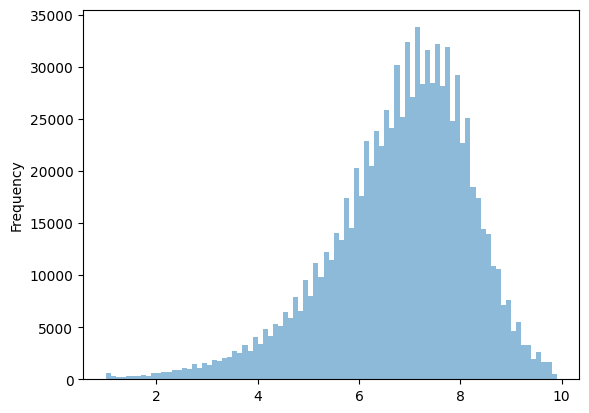

In [54]:
#Previously, we looked at the IMDB rating data as a table but now let’s visualize it with a histogram.
data['averageRating'].plot.hist(
    alpha = 0.5, bins = numpy.arange(1, 10, 0.1))

In [55]:
#We can see from the histogram above that it has a roughly bell shape like a normal distribution.
#However, we can also see it is “positively skewed” towards the higher ratings.
#Just visually inspecting this, I’d guess that it’s “central tendency” is around 6.5.
#Let’s look at some more precise measures of this attribute.
#The pandas library makes this simple.

In [56]:
data['averageRating'].describe()

,averageRating
count,947040.000000
mean,6.868134
std,1.392106
min,1.000000
25%,6.100000
50%,7.000000
75%,7.800000
max,10.000000


In [57]:
#So we can see it has a mean of 6.25 and a median of 6.4.

In [58]:
data['averageRating'].mode()

,averageRating
0,7.2


<Axes: >

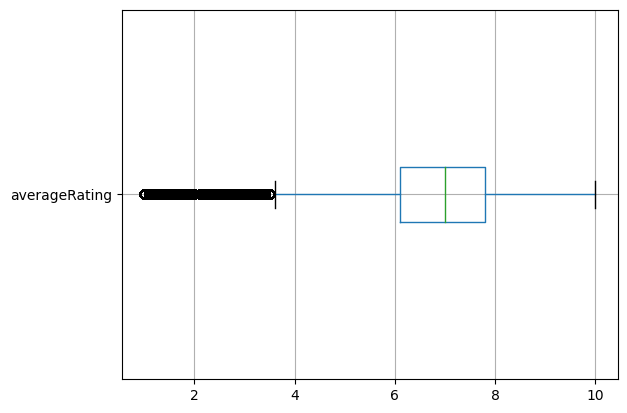

In [59]:
pd.DataFrame.boxplot(
    data, 'averageRating', vert = False,
    return_type = 'axes')

In [68]:
#make sense of this box plot
#Answer:
# The box plot visually represents the distribution of the 'averageRating' data.

# The left edge of the box represents the first quartile (Q1), the 25th percentile of the data.
# This means 25% of the movies have a rating below this value.

# The line inside the box represents the median (Q2), the 50th percentile.
# Half of the movies have a rating below this value, and half above.

# The right edge of the box represents the third quartile (Q3), the 75th percentile.
# 75% of the movies have a rating below this value.

# The "whiskers" extending from the box represent the range of the data, excluding outliers.
# The left whisker extends to the lowest value within 1.5 times the interquartile range (IQR) below Q1.
# The right whisker extends to the highest value within 1.5 times the IQR above Q3.

# The individual points beyond the whiskers represent outliers, values that fall significantly outside the typical range.##


In [69]:
#To get some practice with the pandas libary math functions
import math

In [70]:
print('pandas variance: ' + str(data['averageRating'].var()))
print('pandas standard deviation: ' + str(data['averageRating'].std()))
mean = data['averageRating'].mean()
var = (data['averageRating'].sub(mean).pow(2).sum() /
       data['averageRating'].count())
std = math.sqrt(var)
print('my variance: ' + str(var))
print('my standard deviation: ' + str(std))

pandas variance: 1.9379587130147307
pandas standard deviation: 1.3921058555349628
my variance: 1.9379566666822494
my standard deviation: 1.3921051205574417


In [63]:
mean

6.868133764149351

In [64]:
#what do these numbers mean (variance and standard deviation)?
#Answer:
# Variance:
# It measures how spread out the data points are from the mean (average).
# A higher variance indicates a wider spread of data, while a lower variance suggests data points are closer to the mean.
# In this case, the variance of the average ratings is around 1.9, meaning the ratings are somewhat spread out from the average rating.

# Standard Deviation:
# It's the square root of the variance and provides a more interpretable measure of data spread.
# It represents the average distance of data points from the mean.
# A higher standard deviation indicates greater variability in the data.
# Here, the standard deviation is about 1.39, suggesting that, on average, movie ratings deviate from the mean rating by approximately 1.39 points.


<Axes: xlabel='averageRating', ylabel='numVotes'>

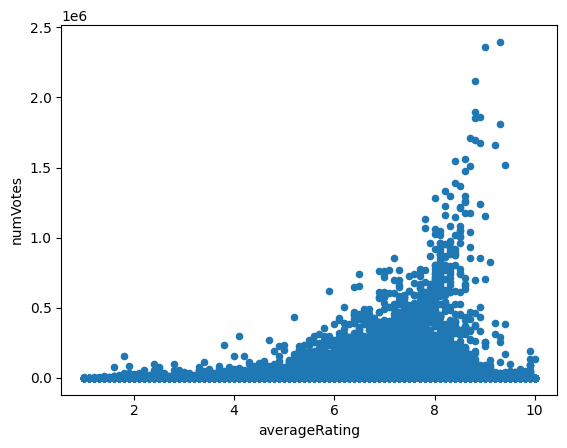

In [65]:
data.plot.scatter('averageRating','numVotes')